In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import norm
from arch import arch_model

# Plot output directory
plot_dir = os.path.join("..", "plots", "eda")
os.makedirs(plot_dir, exist_ok=True)

In [2]:
np.random.seed(42)

T = 10_000      
ALPHA_PI = 0.05    # 95% Confidence

In [3]:
""" Simulation Parameters for AR(1)-ARCH(1) """

mu = 0.05       # Drift
phi = 0.7       # Autoregression
omega = 0.1     # Baseline variance (constant)
alpha = 0.4     # Volatility 'shocks' coefficient (ARCH effect)

y = np.zeros(T)
epsilon = np.zeros(T)
sigma_sq = np.zeros(T)

# Initialize
sigma_sq[0] = omega / (1 - alpha) # Unconditional variance
epsilon[0] = np.random.normal(0, np.sqrt(sigma_sq[0]))
y[0] = mu + epsilon[0]

In [4]:
""" Simulation Loop """
for t in range(1, T):
    # Determine current variance based on previous shock
    sigma_sq[t] = omega + alpha * (epsilon[t-1]**2)
    
    # Generate new shock
    epsilon[t] = np.random.normal(0, np.sqrt(sigma_sq[t]))
    
    # Generate price return
    y[t] = mu + phi * y[t-1] + epsilon[t]

print("Simulation of AR(1)-ARCH(1) complete.")

Simulation of AR(1)-ARCH(1) complete.


In [5]:
""" Fit AR(1)-ARCH(1) to simulated data """

# mean='AR', lags=1 covers the mu + phi*y[t-1] part
# vol='ARCH', p=1 covers the omega + alpha*eps[t-1] part
model = arch_model(y, mean='AR', lags=1, vol='ARCH', p=1)
model_fit = model.fit(disp='off')

print(model_fit.summary())

                           AR - ARCH Model Results                            
Dep. Variable:                      y   R-squared:                       0.467
Mean Model:                        AR   Adj. R-squared:                  0.467
Vol Model:                       ARCH   Log-Likelihood:               -4635.85
Distribution:                  Normal   AIC:                           9279.71
Method:            Maximum Likelihood   BIC:                           9308.55
                                        No. Observations:                 9999
Date:                Thu, Apr 02 2026   Df Residuals:                     9997
Time:                        07:14:10   Df Model:                            2
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
Const          0.0516  3.643e-03     14.153  1.789e-45 [4.

In [6]:
""" Generate Prediction Intervals using ARCH internal fitted values """

# Get the parameters from the fitted model
mu_hat = model_fit.params['Const']
phi_hat = model_fit.params['y[1]']

# Generate the 1-step ahead conditional mean: mu + phi * y[t-1]
# For t in 1...T-1, we predict based on 0...T-2
y_hat = mu_hat + phi_hat * y[:-1]

# Get the conditional volatility (sigma) from the fit
# This is already sigma_t for the full length
# Index [1:] matches y_true
y_std = model_fit.conditional_volatility[1:]

y_true = y[1:]

z = norm.ppf(1 - ALPHA_PI / 2)
lower = y_hat - z * y_std
upper = y_hat + z * y_std

# Final check print
print(f"y_true shape: {y_true.shape}")
print(f"lower shape:  {lower.shape}")
print(f"Check: {len(y_true) == len(lower)}")


y_true shape: (9999,)
lower shape:  (9999,)
Check: True


In [7]:
""" Scoring & Comparison """

def get_metrics(y_true, l, u, alpha=0.05):
    cov = np.mean((y_true >= l) & (y_true <= u))
    wid = np.mean(u - l)
    is_val = np.mean((u - l) + (2/alpha)*np.maximum(l-y_true, 0) + (2/alpha)*np.maximum(y_true-u, 0))
    return cov, wid, is_val

# Baseline: Always Mean (Standard Normal approach)
std_const = np.std(y_true)
l0, u0 = np.mean(y_true) - z*std_const, np.mean(y_true) + z*std_const

results = {
    "AR(1)-ARCH(1) Model": get_metrics(y_true, lower, upper, ALPHA_PI),
    "Baseline: Global Std": get_metrics(y_true, l0, u0, ALPHA_PI)
}

Plot saved to: ../plots/eda/arch_volatility_clustering.pdf


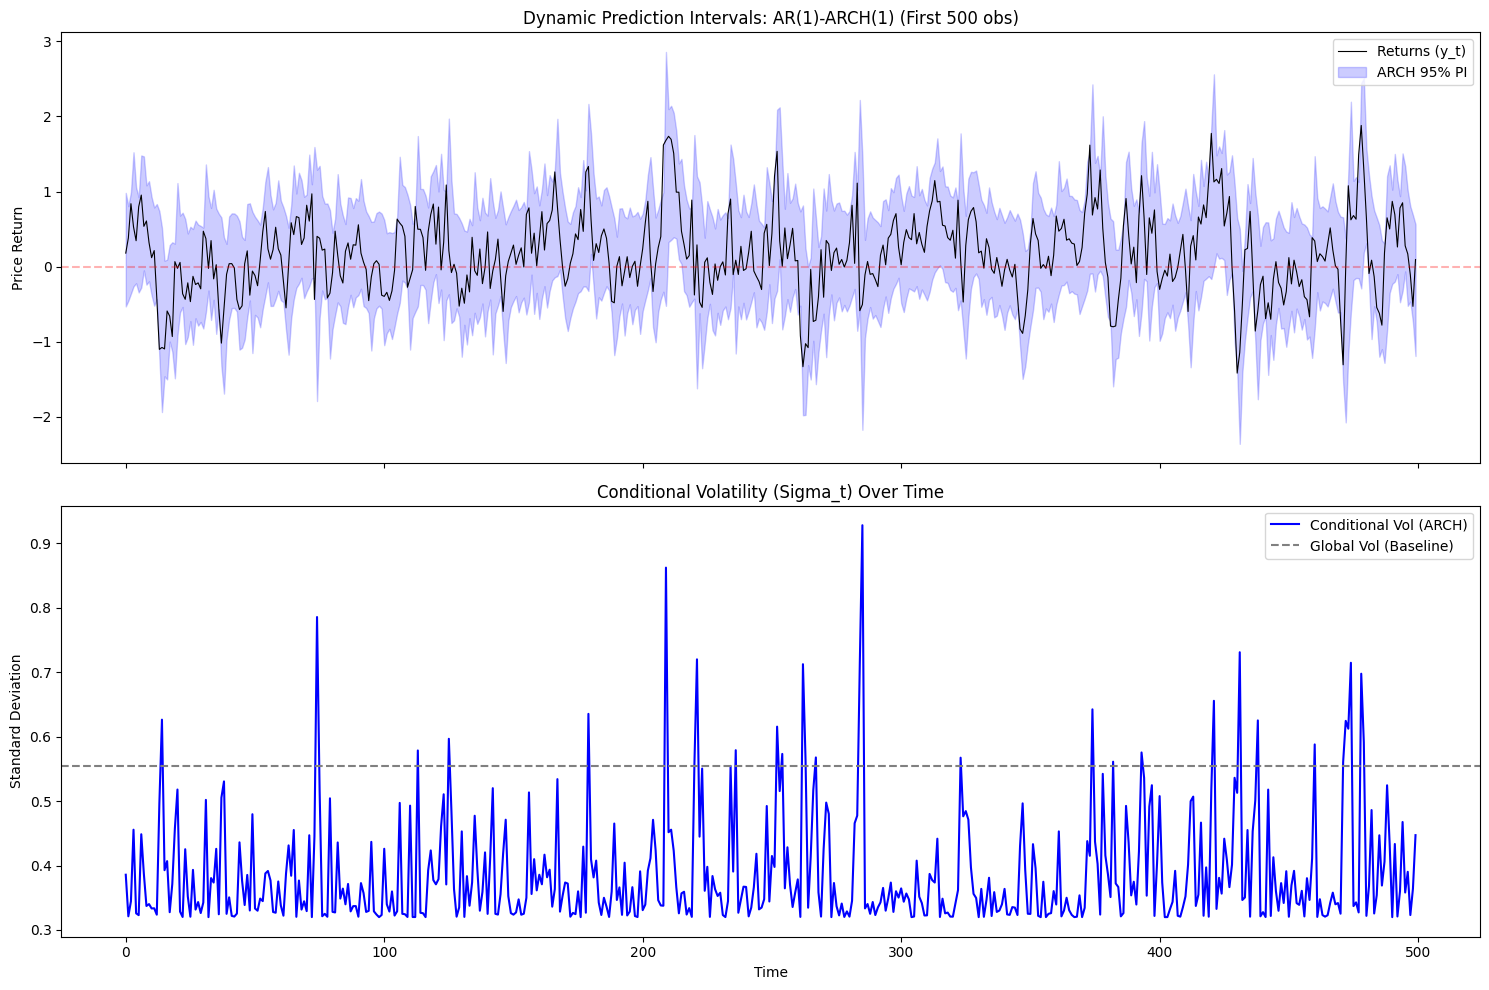

In [8]:
""" Visualizing Volatility Clustering and Prediction Intervals """

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# 1. Top Plot: Returns and PIs (Zoomed in on first 500 points for clarity)
zoom_N = 500
t_range = np.arange(zoom_N)

ax1.plot(t_range, y_true[:zoom_N], color='black', lw=0.8, label='Returns (y_t)')
ax1.fill_between(t_range, lower[:zoom_N], upper[:zoom_N], 
                 color='blue', alpha=0.2, label='ARCH 95% PI')
ax1.axhline(0, color='red', linestyle='--', alpha=0.3)

ax1.set_title(f"Dynamic Prediction Intervals: AR(1)-ARCH(1) (First {zoom_N} obs)")
ax1.set_ylabel("Price Return")
ax1.legend(loc='upper right')

# 2. Bottom Plot: Conditional Volatility (Sigma_t)
# We compare the ARCH sigma to the constant Global Std
ax2.plot(t_range, y_std[:zoom_N], color='blue', lw=1.5, label='Conditional Vol (ARCH)')
ax2.axhline(std_const, color='gray', linestyle='--', label='Global Vol (Baseline)')

ax2.set_title("Conditional Volatility (Sigma_t) Over Time")
ax2.set_xlabel("Time")
ax2.set_ylabel("Standard Deviation")
ax2.legend(loc='upper right')

plt.tight_layout()

# Save the figure
plot_path = os.path.join(plot_dir, "arch_volatility_clustering.pdf")
plt.savefig(plot_path, bbox_inches="tight")
print(f"Plot saved to: {plot_path}")

plt.show()

In [9]:
""" Final Summary for AR(1)-ARCH(1) """

print("=" * 80)
print(f"AR(1)-ARCH(1) SIMULATION SUMMARY".center(80))
print("=" * 80)

print(f"  Sample Size (T): {T:,}")
print(f"  True Parameters: mu={mu}, phi={phi}, omega={omega}, alpha={alpha}")
print(f"  Target Confidence: {100*(1-ALPHA_PI):.1f}%")
print()

print("-" * 80)
print(f"{'Model Profile':<30} | {'Coverage':>10} | {'Avg Width':>10} | {'IS (↓ lower)':>12}")
print("-" * 80)

for name, metrics in results.items():
    cov, wid, is_val = metrics
    check = " ✓" if "ARCH" in name else ""
    print(f"{name:<30} | {cov:>10.4f} | {wid:>10.4f} | {is_val:>12.4f}{check}")

print("-" * 80)

arch_score = results["AR(1)-ARCH(1) Model"][2]
base_score = results["Baseline: Global Std"][2]
improvement = 100 * (base_score - arch_score) / base_score
print(f"  CONCLUSION: ARCH model improved IS by {improvement:.2f}% over global baseline.")
print("=" * 80)

                        AR(1)-ARCH(1) SIMULATION SUMMARY                        
  Sample Size (T): 10,000
  True Parameters: mu=0.05, phi=0.7, omega=0.1, alpha=0.4
  Target Confidence: 95.0%

--------------------------------------------------------------------------------
Model Profile                  |   Coverage |  Avg Width | IS (↓ lower)
--------------------------------------------------------------------------------
AR(1)-ARCH(1) Model            |     0.9489 |     1.5450 |       1.8454 ✓
Baseline: Global Std           |     0.9459 |     2.1722 |       2.8688
--------------------------------------------------------------------------------
  CONCLUSION: ARCH model improved IS by 35.67% over global baseline.
